1️⃣ Imports & Setup

In [28]:
# forecasting_models.ipynb - Task 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

# Set paths
processed_path = Path("../data/processed")
models_path = Path("../models")
figures_path = Path("../figures")

# Ensure figures folder exists
figures_path.mkdir(parents=True, exist_ok=True)

# Load processed TSLA data
tsla_data = pd.read_csv(processed_path / "TSLA_cleaned.csv", index_col="Date", parse_dates=True)
tsla_data = tsla_data.sort_index()

# Display basic info
print(tsla_data.head())
print(tsla_data.tail())


                Close       High        Low       Open    Volume    Return  \
Date                                                                         
2015-02-02  14.062667  14.130000  13.553333  13.598000  62238000  0.036051   
2015-02-03  14.557333  14.691333  14.084667  14.214667  72393000  0.035176   
2015-02-04  14.570000  14.765333  14.453333  14.552667  49581000  0.000870   
2015-02-05  14.732667  15.032000  14.642667  14.658667  52843500  0.011165   
2015-02-06  14.490667  14.893333  14.433333  14.800000  48658500 -0.016426   

            RollingVol  
Date                    
2015-02-02    0.024221  
2015-02-03    0.023592  
2015-02-04    0.023579  
2015-02-05    0.023651  
2015-02-06    0.024019  
                 Close        High         Low        Open    Volume  \
Date                                                                   
2026-01-08  435.799988  436.890015  424.369995  427.890015  57041100   
2026-01-09  445.010010  449.049988  430.390015  435.950012  67

2️⃣ Load Trained ARIMA Model

In [29]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Compute returns if not already done
tsla_returns = tsla_data["Close"].pct_change().dropna()

# 2. Fit ARIMA model
# Use the same order you used in Task 2
p, d, q = 2, 1, 2  
arima_model_fitted = ARIMA(tsla_returns, order=(p,d,q)).fit()

# 3. Confirm it's fitted
print(type(arima_model_fitted))
# Should print: <class 'statsmodels.tsa.arima.model.ARIMAResults'>
print(arima_model_fitted.summary())


c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting p

<class 'statsmodels.tsa.arima.model.ARIMAResultsWrapper'>
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2754
Model:                 ARIMA(2, 1, 2)   Log Likelihood                5209.694
Date:                Sun, 25 Jan 2026   AIC                         -10409.388
Time:                        18:03:11   BIC                         -10379.786
Sample:                             0   HQIC                        -10398.693
                               - 2754                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9974      0.092    -10.866      0.000      -1.177      -0.818
ar.L2         -0.0077      0.014     -0.541      0.588      -0.036       

3️⃣ Generate 6–12 Month Forecast

In [21]:
horizons = {"6_months": 126, "12_months": 252}
forecast_results = {}

for label, steps in horizons.items():
    forecast_obj = arima_model_fitted.get_forecast(steps=steps)
    forecast_mean = forecast_obj.predicted_mean
    conf_int = forecast_obj.conf_int(alpha=0.05)  # 95% CI
    
    forecast_results[label] = {
        "mean": forecast_mean,
        "lower": conf_int.iloc[:, 0],
        "upper": conf_int.iloc[:, 1]
    }


c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\derej\Desktop\Kifya\LSTM\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


5️⃣ Visualization with Confidence Intervals

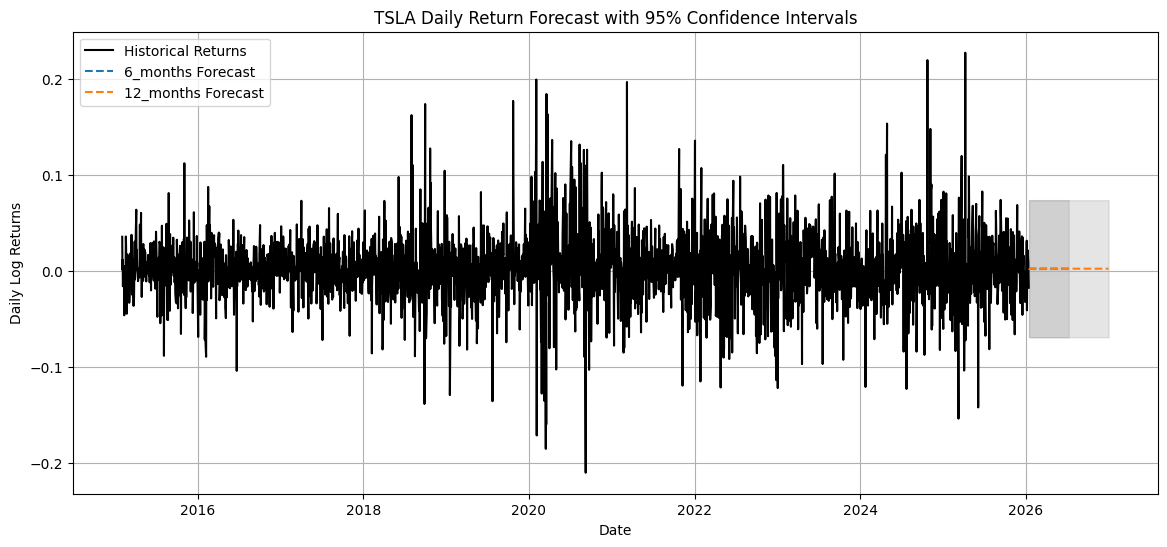

In [30]:
plt.figure(figsize=(14,6))

# Historical returns
plt.plot(tsla_returns.index, tsla_returns, label="Historical Returns", color="black")

# Forecast returns + confidence intervals
for label, steps in horizons.items():
    forecast_index = pd.date_range(tsla_returns.index[-1] + pd.Timedelta(days=1),
                                   periods=steps, freq='B')
    
    # Mean forecast
    plt.plot(forecast_index, forecast_results[label]["mean"], 
             label=f"{label} Forecast", linestyle="--")
    
    # Confidence interval
    plt.fill_between(forecast_index,
                     forecast_results[label]["lower"],
                     forecast_results[label]["upper"],
                     color='gray', alpha=0.2)

plt.title("TSLA Daily Return Forecast with 95% Confidence Intervals")
plt.xlabel("Date")
plt.ylabel("Daily Log Returns")
plt.legend()
plt.grid(True)

# Save figure
plt.savefig("../figures/tsla_return_forecast_ci.png", dpi=300)
plt.show()
